In [1]:
%matplotlib widget
import inspect
import math
import re

import matplotlib.pyplot as plt
import numpy as np
import torch
import warp as wp

from warpSPHCore import *
from warpSPHCore.util import generateNeighborTestData

# Initialize Warp
wp.config.verify_autograd_array_access = False
wp.config.verbose = False
wp.init()

def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r, type(x).__name__, x))

def plot_scalar_field(ax, positions, values, title, *, cmap="viridis", marker_size=2, domain=None):
    sc = ax.scatter(positions[:, 0].cpu(), positions[:, 1].cpu(), c=values.cpu(), cmap=cmap, s=marker_size)
    ax.figure.colorbar(sc, ax=ax, shrink=0.95)
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect("equal")
    if domain is not None:
        ax.set_xlim(domain.min[0].item(), domain.max[0].item())
        ax.set_ylim(domain.min[1].item(), domain.max[1].item())
    return sc

def plot_vector_components(fig, axes, positions, tensor_field, title_prefix, *, marker_size=2, domain=None, cmap="RdBu_r"):
    component_titles = [(0, 0), (0, 1), (1, 0), (1, 1)]
    for ax, (row, col) in zip(axes.flat, component_titles):
        component = tensor_field[:, row, col]
        sc = ax.scatter(positions[:, 0].cpu(), positions[:, 1].cpu(), c=component.cpu(), cmap=cmap, s=marker_size)
        ax.figure.colorbar(sc, ax=ax, shrink=0.95)
        ax.set_title(f"{title_prefix} [{row},{col}]")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_aspect("equal")
        if domain is not None:
            ax.set_xlim(domain.min[0].item(), domain.max[0].item())
            ax.set_ylim(domain.min[1].item(), domain.max[1].item())
        fig.colorbar(sc, ax=ax, shrink=0.95)


Warp DeprecationWarning: warp.config.verbose is deprecated; use warp.config.log_level = warp.LOG_DEBUG instead.


Warp 1.15.0 initialized:
   CUDA Toolkit 12.9, Driver 13.3
   Devices:
     "cpu"      : "CPU"
     "cuda:0"   : "NVIDIA GeForce RTX 3090" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/veldora/.cache/warp/1.15.0


In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
targetNumNeighbors = 50
nx = 128
dim = 2
numParticles = nx ** dim

warpOnly = False
periodic = True
field_mode = "periodic_sinusoidal"  # "linear" or "periodic_sinusoidal"
mask_edge_particles = True  # used for linear fields to hide the periodic jump at the boundaries
jitter = 0.05
linear_slope_x = 5.0
linear_slope_y = 1.0
linear_slope_z = 2.0

kernel = KernelFunctions.Wendland2
supportMode = SupportScheme.Gather

markerSize = 8 if warpOnly else 2
gridVisualization = False
gridResolution = 128
dx = 2.0 / nx


In [3]:
n_samples = 10
measure_cuda = True
warm_start = True


In [4]:
from profile_util import *

In [5]:
def run_benchmark(
        nx, targetNumNeighbors, dim, periodic, device, jitter, field_mode,
        linear_slope_x, linear_slope_y, linear_slope_z,
        n_samples, measure_cuda, warm_start,
        eval_grid, eval_adjacency, eval_crk, eval_renorm, eval_density,
        eval_interpolate, eval_gradient, eval_laplacian, eval_curl, eval_divergence,
        eval_vector_field, eval_matrix_field
):

    particles, adjacency, domain, dx, scalar_field, vector_field, matrix_field = generateData(
        nx, targetNumNeighbors, dim, periodic, device, jitter, field_mode, linear_slope_x, linear_slope_y, linear_slope_z
    )

    timings = measure_timings(
        particles, adjacency, domain, kernel, scalar_field, vector_field, matrix_field,
        nx, dim, targetNumNeighbors, periodic, jitter, n_samples, measure_cuda, warm_start,
        eval_grid = eval_grid,
        eval_adjacency = eval_adjacency,
        eval_crk = eval_crk,
        eval_renorm = eval_renorm,
        eval_density = eval_density,
        eval_interpolate = eval_interpolate,
        eval_gradient = eval_gradient,
        eval_laplacian = eval_laplacian,
        eval_curl = eval_curl,
        eval_divergence = eval_divergence,
        eval_vector_field = eval_vector_field,
        eval_matrix_field = eval_matrix_field
    )

    return timings

In [6]:
from tqdm.autonotebook import tqdm

/tmp/ipykernel_41250/987820437.py:1: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [40]:
eval_grid = False
eval_adjacency = True
eval_crk = True
eval_renorm = True
eval_density = True
eval_interpolate = True
eval_gradient = True
eval_laplacian = True
eval_curl = True
eval_divergence = True
eval_vector_field = True
eval_matrix_field = True

benchmark_results = []

numParticles = np.logspace(7, 20, num=32, base=2, dtype=int)  # 2^2 to 2^7
print(f"Benchmarking for numParticles: {numParticles}")
nxs = numParticles ** (1 / dim)  # Calculate nx for each number of particles
nxs = nxs.astype(int)  # Convert to integer values

# nxs = [32, 64, 128, 256, 512, 1024, 2048]
dims = [2]
n_samples = 8

for nx in (tqnx:=tqdm(nxs)):
    tqnx.set_description(f"Benchmarking nx={nx}")
    for dim in (tqdims:=tqdm(dims, leave=False)):
        tqdims.set_description(f"Benchmarking dim={dim}")
        results = run_benchmark(
            nx, targetNumNeighbors, dim, periodic, device, jitter, field_mode,
            linear_slope_x, linear_slope_y, linear_slope_z,
            n_samples, measure_cuda, warm_start,
            eval_grid = eval_grid,
            eval_adjacency = eval_adjacency,
            eval_crk = eval_crk,
            eval_renorm = eval_renorm,
            eval_density = eval_density,
            eval_interpolate = eval_interpolate,
            eval_gradient = eval_gradient,
            eval_laplacian = eval_laplacian,
            eval_curl = eval_curl,
            eval_divergence = eval_divergence,
            eval_vector_field = eval_vector_field,
            eval_matrix_field = eval_matrix_field
        )
        benchmark_results.extend(results)

Benchmarking for numParticles: [    128     171     228     306     409     547     732     979    1309
    1751    2342    3132    4188    5601    7491   10018   13397   17916
   23960   32043   42852   57308   76639  102492  137066  183303  245136
  327828  438414  586304  784082 1048576]


  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Module warpSPHCore.crk.crk_volume 401651a load on device 'cuda:0' took 1.73 ms  (cached)
Module warpSPHCore.crk.crk_moments 6686e30 load on device 'cuda:0' took 2.44 ms  (cached)
Module warpSPHCore.crk.crk_density efa2365 load on device 'cuda:0' took 2.38 ms  (cached)
Module warpSPHCore.renorm.wp_covariance dd0a224 load on device 'cuda:0' took 5.78 ms  (cached)


  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [41]:
import pandas as pd
import seaborn as sns

In [42]:
dataset = pd.DataFrame(benchmark_results)
# display(dataset)
dataset['numParticles'] = dataset['nx'] ** dataset['dim']


dataset['cpuTimes_avg'] = dataset['times'].apply(lambda x: np.mean(np.array(x)[:,0]) if isinstance(x, list) else x)
dataset['gpuTimes_avg'] = dataset['times'].apply(lambda x: np.mean(np.array(x)[:,1]) if isinstance(x, list) else x)

# dataset['fieldType'] = dataset.apply(lambda row: 'scalar' if row['operation'] == 'density' else row['fieldType'])

# dataset times is an array of shape (n_samples, 2) where the first column is CPU times and the second column is GPU times
# We want to flatten this into a long format for easier plotting with seaborn

dataset_long = dataset.explode('times')
dataset_long['cpuTimes'] = dataset_long['times'].apply(lambda x: x[0] if isinstance(x, (list, np.ndarray, tuple)) else x)
dataset_long['gpuTimes'] = dataset_long['times'].apply(lambda x: x[1] if isinstance(x, (list, np.ndarray, tuple)) else x)


In [43]:
# dataset[np.logical_and(dataset['operation'] == 'density', dataset['adjacency'] == True)]

In [44]:
plot_dataset = dataset_long

dataset_operations_only = plot_dataset[np.logical_and(np.logical_and(plot_dataset['operation'] != 'adjacency', plot_dataset['operation'] != 'renorm'), plot_dataset['operation'] != 'crk')]
dataset_adjacency_only = plot_dataset[plot_dataset['operation'] == 'adjacency']
dataset_crk_only = plot_dataset[plot_dataset['operation'] == 'crk']
dataset_renorm_only = plot_dataset[plot_dataset['operation'] == 'renorm']

In [45]:
dataset_adjacency_only

,operation,adjacency,times,fieldType,nx,dim,targetNumNeighbors,periodic,jitter,num_samples,measure_cuda,warm_start,numParticles,cpuTimes_avg,gpuTimes_avg,cpuTimes,gpuTimes
0,adjacency,False,"(0.018727779388427734, 0.02654412841796875)",NaN,11,2,50,True,0.05,8,True,True,121,0.015183,0.016668,0.018728,0.026544
0,adjacency,False,"(0.023531436920166016, 0.024427520751953126)",NaN,11,2,50,True,0.05,8,True,True,121,0.015183,0.016668,0.023531,0.024428
0,adjacency,False,"(0.015469074249267578, 0.016220159530639648)",NaN,11,2,50,True,0.05,8,True,True,121,0.015183,0.016668,0.015469,0.016220
0,adjacency,False,"(0.015631914138793945, 0.015941632270812987)",NaN,11,2,50,True,0.05,8,True,True,121,0.015183,0.016668,0.015632,0.015942
0,adjacency,False,"(0.013623476028442383, 0.013913087844848633)",NaN,11,2,50,True,0.05,8,True,True,121,0.015183,0.016668,0.013623,0.013913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
434,adjacency,False,"(0.02390289306640625, 0.04901068878173828)",NaN,1024,2,50,True,0.05,8,True,True,1048576,0.025028,0.049717,0.023903,0.049011
434,adjacency,False,"(0.023639917373657227, 0.04706816101074219)",NaN,1024,2,50,True,0.05,8,True,True,1048576,0.025028,0.049717,0.023640,0.047068
434,adjacency,False,"(0.023020267486572266, 0.048589824676513675)",NaN,1024,2,50,True,0.05,8,True,True,1048576,0.025028,0.049717,0.023020,0.048590
434,adjacency,False,"(0.024981975555419922, 0.049377281188964846)",NaN,1024,2,50,True,0.05,8,True,True,1048576,0.025028,0.049717,0.024982,0.049377


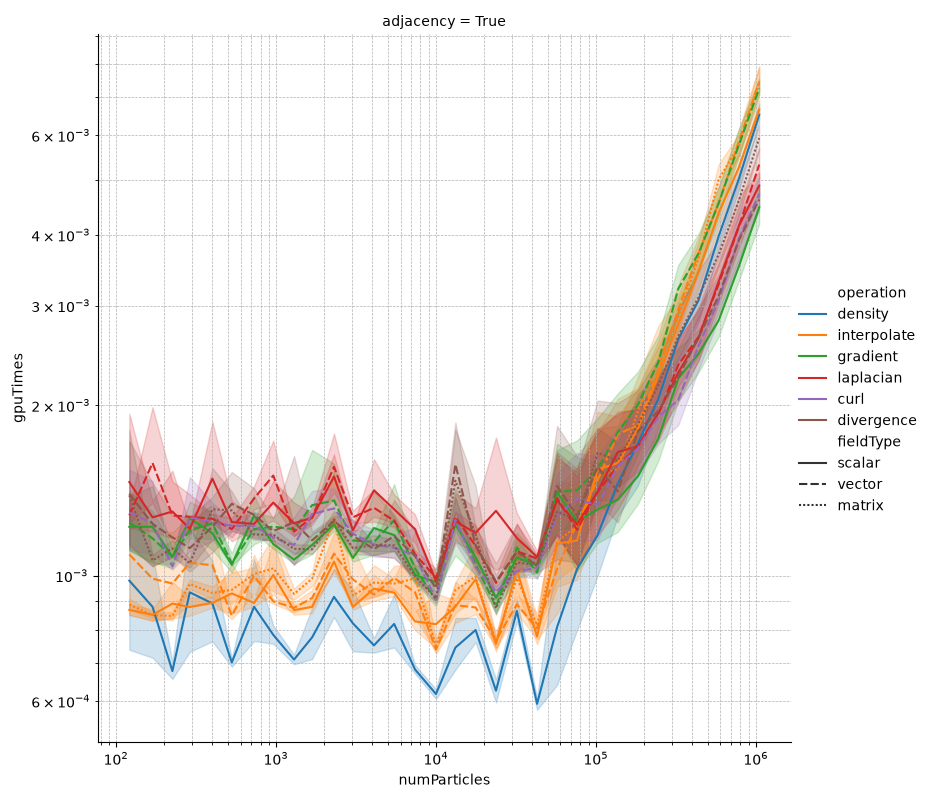

In [46]:
g = sns.relplot(data=dataset_operations_only[dataset_operations_only['dim'] == 2], x="numParticles", y="gpuTimes", hue="operation", style="fieldType", kind="line", markers=False, col='adjacency', height = 8)
# g.set(xscale="log")

# show grid and set log scale for x-axis
for ax in g.axes.flat:
    ax.grid(True, which="both", ls="--", lw=0.5)
    ax.set_xscale("log")
    ax.set_yscale("log")


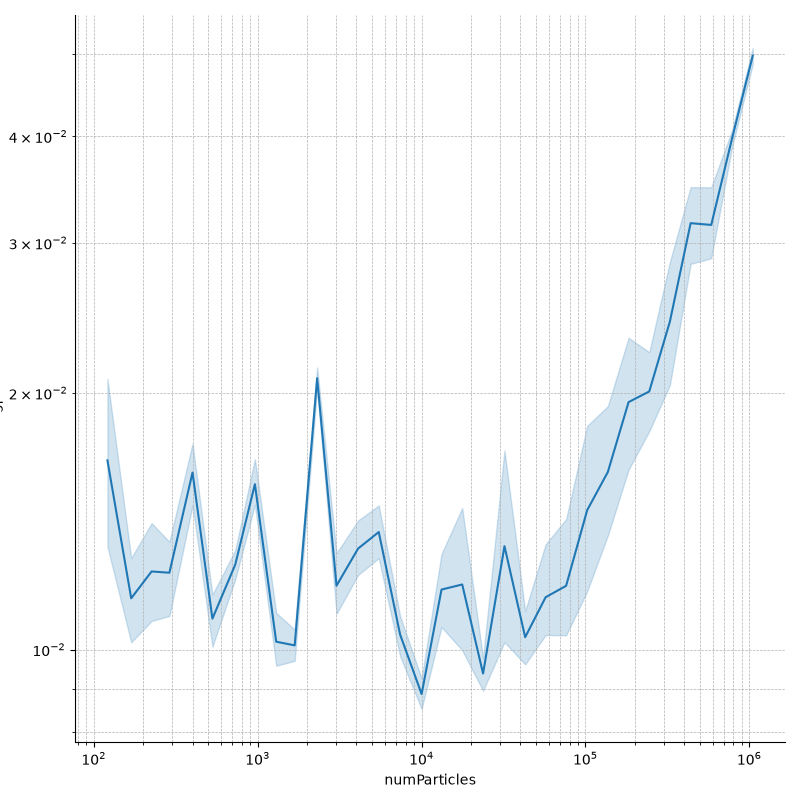

In [47]:
g = sns.relplot(data=dataset_adjacency_only[dataset_adjacency_only['dim'] == 2], x="numParticles", y="gpuTimes", kind="line", markers=False, height = 8)
# g.set(xscale="log")

# show grid and set log scale for x-axis
for ax in g.axes.flat:
    ax.grid(True, which="both", ls="--", lw=0.5)
    ax.set_xscale("log")
    ax.set_yscale("log")


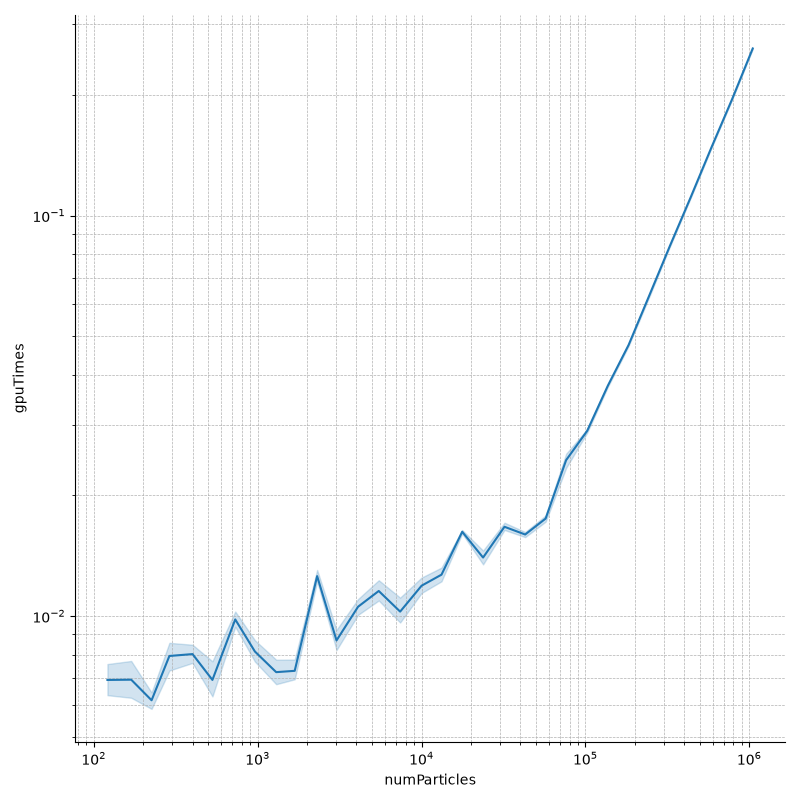

In [48]:
g = sns.relplot(data=dataset_crk_only[dataset_crk_only['dim'] == 2], x="numParticles", y="gpuTimes", kind="line", markers=False, height = 8)
# g.set(xscale="log")

# show grid and set log scale for x-axis
for ax in g.axes.flat:
    ax.grid(True, which="both", ls="--", lw=0.5)
    ax.set_xscale("log")
    ax.set_yscale("log")


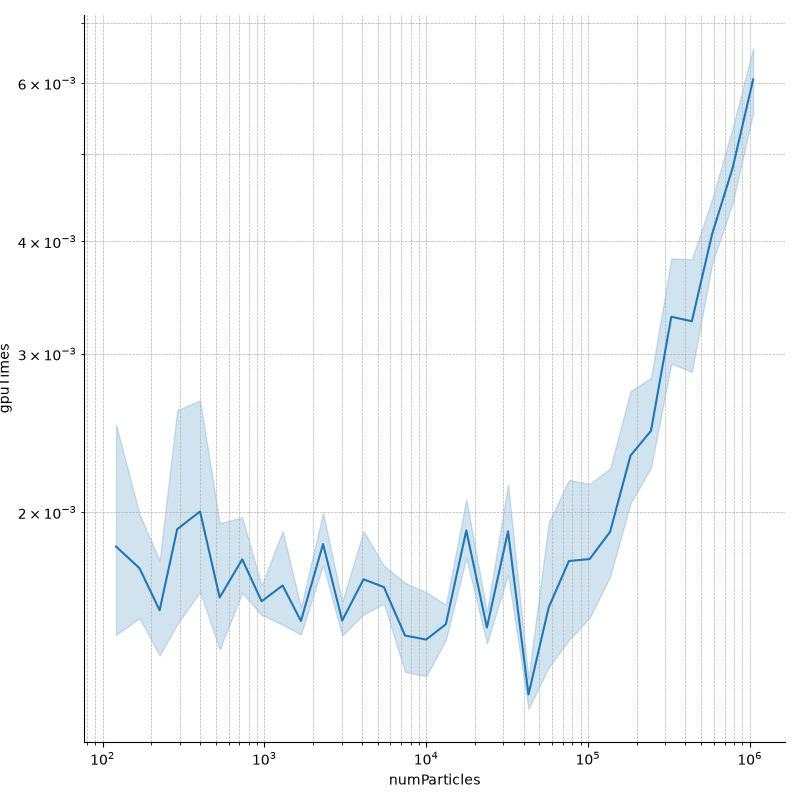

In [49]:
g = sns.relplot(data=dataset_renorm_only[dataset_renorm_only['dim'] == 2], x="numParticles", y="gpuTimes", kind="line", markers=False, height = 8)
# g.set(xscale="log")

# show grid and set log scale for x-axis
for ax in g.axes.flat:
    ax.grid(True, which="both", ls="--", lw=0.5)
    ax.set_xscale("log")
    ax.set_yscale("log")
